# Session 2: Python for R users  

JSM 2026 workshop material created by Ethan Meyers (Ethan.Meyers@gmail.com)

This notebook continues from Session 1. We cover the following topics: 

**Topics:**
1. Pandas: data manipulation
2. Seaborn: statistical graphics
3. StatsModels and Scipy:  statistical modeling
4. Scikit-learn:  machine learning
5. Object-oriented programming and duck typing


In [11]:
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install pandas-datareader

import numpy as np
import matplotlib.pyplot as plt


---
## 1. Pandas

Pandas is a python package that provides two core data structures:

- **Series**: a 1D labeled NumPy array - like a named R vector
- **DataFrame**: a 2D labeled table - like an R data frame

Every DataFrame and Series carries an **Index**, a set of row labels that many operations use and return. 

Let's start by examining pandas **Series** by looking at the monthly retail price of one dozen large eggs (FRED, series `APU0000708111`). The data is loaded below.

In [12]:
import pandas as pd
from pandas_datareader import data as pdr

# Fetch the monthly egg price series from FRED
try:
    egg_df = pdr.DataReader("APU0000708111", "fred", start="2000-01-01")
    egg_df = (egg_df
              .rename(columns={"APU0000708111": "price_per_dozen"})
              .reset_index()
              .rename(columns={"DATE": "date"})
              .dropna())
except Exception:
    # No internet? Load the cached copy instead.
    egg_df = pd.read_csv("data/egg_prices.csv", parse_dates=["date"])

# Make the date the Index, then squeeze the single remaining column to a Series
eggs = egg_df.set_index("date").squeeze("columns")

### 1.1 Loading Data & First Look

A few basic operations we can perform are: 

| Goal | R | Pandas |
|------|---|--------|
| Read a CSV | `read.csv("file.csv")` | `pd.read_csv("file.csv")` |
| First rows | `head(df)` | `df.head()` |
| Dimensions | `dim(df)` | `df.shape` |
| Structure | `str(df)` | `df.info()` |
| Summary statistics | `summary(df)` | `df.describe()` |

In [13]:
# The eggs price data is read in as a Series above

# Print the type of data in the eggs name
print(type(eggs))

# The .shape property gets the dimensions; like R's dim()
print(eggs.shape)

# The .info() method gets column types; like R's str()
eggs.info()

# The .describe() method gets summary statistics; like R's summary()
print(eggs.describe())

# First five rows
eggs.head()

<class 'pandas.Series'>
(317,)
<class 'pandas.Series'>
DatetimeIndex: 317 entries, 2000-01-01 to 2026-06-01
Series name: price_per_dozen
Non-Null Count  Dtype  
--------------  -----  
317 non-null    float64
dtypes: float64(1)
memory usage: 5.0 KB
count    317.000000
mean       1.829593
std        0.804202
min        0.838000
25%        1.332000
50%        1.670000
75%        2.007000
max        6.227000
Name: price_per_dozen, dtype: float64


date
2000-01-01    0.975
2000-02-01    0.962
2000-03-01    0.931
2000-04-01    0.939
2000-05-01    0.852
Name: price_per_dozen, dtype: float64

### 1.1b Pandas Series: `.loc[]` and `.iloc[]`

We can extract values from a Series (or a DataFrame) by either integer position or by Index label. 

| Method | Meaning | Example |
|--------|---------|----------|
| `.iloc[position]` | Rows by **integer position** | `df.iloc[0]` (first row) |
| `.loc[label]` | Rows by **label** | `df.loc["2020-01-01"]` |

> ⚠️ **Pitfall:** `.iloc` slices follow the Session 1 rules and exclude the stop (`df.iloc[0:3]` gives three rows). `.loc` slices *include* the stop label (`df.loc["2020":"2022"]` includes 2022).

In [14]:
# .iloc: first row by position
print(eggs.iloc[0])

# .iloc: last 5 rows
print(eggs.iloc[-5:])

# .loc: row by date label (uses the index we just set)
print(eggs.loc["2022-01-01"])

# .loc to get data between Jan 1st 2010 and Jan 1st 2020
eggs.loc["2010-01-01":"2020-01-01"]

0.975
date
2026-02-01    2.500
2026-03-01    2.348
2026-04-01    2.250
2026-05-01    2.191
2026-06-01    2.141
Name: price_per_dozen, dtype: float64
1.929


date
2010-01-01    1.789
2010-02-01    1.872
2010-03-01    1.822
2010-04-01    1.779
2010-05-01    1.523
              ...  
2019-09-01    1.383
2019-10-01    1.282
2019-11-01    1.405
2019-12-01    1.535
2020-01-01    1.461
Name: price_per_dozen, Length: 121, dtype: float64

### 1.2 Pandas DataFrames

Let's explore pandas DataFrames by looking at some economic data from the [Federal Reserve Bank of St. Louis (FRED)](https://fred.stlouisfed.org/). We will read in the data directly from FRED using pandas DataReader. 


In [15]:
from pandas_datareader import data as pdr

# Fetch three series from FRED: sticky CPI, unemployment rate, and regular gas price
try:
    econ = pdr.DataReader(['CORESTICKM159SFRBATL', 'UNRATE', 'GASREGCOVM'],
                          'fred', start='2015-01-01', end='2025-01-01')
    econ = econ.rename(columns={'CORESTICKM159SFRBATL': 'CPI',
                                'UNRATE': 'unrate',
                                'GASREGCOVM': 'gas'})
except Exception:
    # No internet? Load the cached copy instead.
    econ = pd.read_csv("data/econ.csv", parse_dates=["DATE"], index_col="DATE")

display(econ.head())

,CPI,unrate,gas
DATE,,,
2015-01-01,1.976365,5.7,2.046
2015-02-01,1.972517,5.5,2.152
2015-03-01,1.989606,5.4,2.352
2015-04-01,2.053710,5.4,2.369
2015-05-01,2.056561,5.6,2.578


#### Selecting Columns

We can select columns from a DataFrame as either a Series or as a DataFrame. In particular, the bracket count matters: `df["col"]` (a string) returns a Series, while `df[["col"]]` (a list of strings) returns a one-column DataFrame. 

| Goal | R | Pandas |
|------|---|--------|
| One column, as a vector | `df$col` | `df["col"]` returns a **Series** |
| Several columns, as a table | `df[, c("a","b")]` | `df[["a","b"]]` returns a **DataFrame** |



In [16]:
# Return a Series with the gas price
gas_series = econ['gas']  
print(type(gas_series))

# Returns a DataFrame with the gas
gas_df = econ[['gas']]  
print(type(gas_df))

<class 'pandas.Series'>
<class 'pandas.DataFrame'>


#### Filtering for a subset of rows

We can filter for a subset of rows using a Boolean condition, much like logical subsetting in R:

| Goal | R | Pandas |
|------|---|--------|
| Filter by a condition | `df[df$unrate > 5, ]` | `df[df["unrate"] > 5]` |
| Filter with subset()-style syntax | `subset(df, unrate > 5)` | `df.query("unrate > 5")` |

> Note: the trailing comma in R (`df[condition, ]`) is required; Pandas doesn't use it.
>
> Combining conditions follows the NumPy rules from Session 1: parentheses around each condition, and `&` / `|` rather than `and` / `or`. For example, `df[(df["unrate"] > 5) & (df["gas"] < 3)]`.

In [17]:
# Filter: months where the unemployment rate is above 5%
print(econ[econ["unrate"] > 5.00].head())

# Filter using .query(): readable string syntax
print(econ.query("unrate > 5.00").head())

                 CPI  unrate    gas
DATE                               
2015-01-01  1.976365     5.7  2.046
2015-02-01  1.972517     5.5  2.152
2015-03-01  1.989606     5.4  2.352
2015-04-01  2.053710     5.4  2.369
2015-05-01  2.056561     5.6  2.578
                 CPI  unrate    gas
DATE                               
2015-01-01  1.976365     5.7  2.046
2015-02-01  1.972517     5.5  2.152
2015-03-01  1.989606     5.4  2.352
2015-04-01  2.053710     5.4  2.369
2015-05-01  2.056561     5.6  2.578


### Adding and Modifying Columns

We can add columns to a DataFrame using the syntax below which is similar to the dplyr `mutate()` function. Note, this modifies the original DataFrame so it is often useful to make a copy of the original DataFrame first if one needs the unmodified data. 

| Goal | R | Pandas |
|------|---|--------|
| Add or overwrite a column | `df$new <- expr` | `df["new"] = expr` |
| Mutate-style | `dplyr::mutate(df, new = expr)` | `df["new"] = expr` or `df.assign(new=expr)` |

In [ ]:
# Create a copy of the data to keep the original unmodified
econ2 = econ.copy()

# Add a column
econ2["gas_inflate_adj"] = econ2["gas"]/econ["CPI"]

# Add a column using the assign() method
econ2 = econ2.assign(gas_inflate_adj2 = econ2["gas"]/econ2["CPI"])

# Add a column: rolling 12-month average
econ2["rolling_12m"] = econ2["unrate"].rolling(12).mean()

econ2.tail()

,CPI,unrate,gas,gas_inflate_adj,gas_inflate_adj2,rolling_12m
DATE,,,,,,
2024-09-01,4.011582,4.1,3.106,0.774258,0.774258,3.941667
2024-10-01,3.975247,4.1,3.036,0.763726,0.763726,3.958333
2024-11-01,3.890823,4.2,2.958,0.760251,0.760251,4.000000
2024-12-01,3.752907,4.1,2.926,0.779662,0.779662,4.025000
2025-01-01,3.624696,4.0,2.981,0.822414,0.822414,4.050000


> ⚠️ **Pitfall: assign through `.loc`, not through a chained selection**
>
> Writing through two selections in a row, as in `df[df["year"] > 2020]["price_cents"] = 0`, never works: the first selection returns a copy, so the assignment lands on a temporary object and Pandas warns with a `ChainedAssignmentError`. Select the rows and the column in a single `.loc` call instead.
>
> This is the Pandas version of Session 1's copies-and-views story.

In [19]:
demo = econ[["unrate", "gas"]].copy()

# BAD: chained assignment never works (warns, and demo is unchanged)
#demo[demo["gas"] > 3.00]["gas"] = 3.00

# GOOD: one .loc call selecting rows and column together
demo.loc[demo["gas"] > 3.00, "gas"] = 3.00
print(demo["gas"].max())   # 3.0

3.0


### GroupBy

We can do operations separately by using pandas `groupby()` method which is very similar to dplyr's `group_by()` function. 


| Goal | R (dplyr) | Pandas |
|------|-----------|--------|
| Grouped summary | `df %>% group_by(col) %>% summarize(m = mean(val))` | `df.groupby("col")["val"].mean()` |
| Several summaries at once | `df %>% group_by(col) %>% summarize(m = mean(val), n = n())` | `df.groupby("col")["val"].agg(["mean", "count"])` |

> The result's row labels are the group values: this is the **index** at work. Call `.reset_index()` on the result if you want the groups back as a regular column.

In [20]:
# Create a year column from the DatetimeIndex
econ["year"] = econ.index.year


# Mean gas price by year
gas_price_yearly = econ.groupby("year")["gas"].mean().round(2)
print(gas_price_yearly)   # view the type


# Reset the index to make year a column again
gas_price_yearly = gas_price_yearly.reset_index()
print(gas_price_yearly)  # view the type


# Multiple aggregations by year
econ.groupby("year")["gas"].agg(["mean", "min", "max", "count"]).round(2)

year
2015    2.33
2016    2.07
2017    2.34
2018    2.64
2019    2.49
2020    2.08
2021    2.90
2022    3.81
2023    3.40
2024    3.19
2025    2.98
Name: gas, dtype: float64
    year   gas
0   2015  2.33
1   2016  2.07
2   2017  2.34
3   2018  2.64
4   2019  2.49
5   2020  2.08
6   2021  2.90
7   2022  3.81
8   2023  3.40
9   2024  3.19
10  2025  2.98


,mean,min,max,count
year,,,,
2015,2.33,1.95,2.70,12
2016,2.07,1.68,2.30,12
2017,2.34,2.21,2.57,12
2018,2.64,2.26,2.81,12
2019,2.49,2.14,2.73,12
2020,2.08,1.72,2.46,12
2021,2.90,2.24,3.28,12
2022,3.81,3.08,4.76,12
2023,3.40,3.01,3.73,12


The most versatile form for creating statistics by group is to use the syntax:

```python

df.group_by("group_col").agg(
    output_col1 = ("input_col1", "stat_function_name1"),
    output_col2 = ("input_col2", "stat_function_name2"),
    output_col3 = ("input_col2", "stat_function_name3"),
)

```

This operates in a very similar way as to using dplyr's `summary()` function. 

In [21]:
# Aggregate statistics for multiple columns (variables) similar to dplyr groupby() and summarize()
econ.groupby("year").agg(
    mean_gas = ('gas', 'mean'),
    max_unemploy = ('unrate', 'max'),
    min_inflation = ('CPI', 'min')
)

,mean_gas,max_unemploy,min_inflation
year,,,
2015,2.327000,5.7,1.972517
2016,2.072333,5.1,2.460879
2017,2.335417,4.7,2.075047
2018,2.635083,4.1,2.123101
2019,2.494417,4.0,2.356946
2020,2.075083,14.8,1.603908
2021,2.902000,6.4,1.388292
2022,3.809167,4.0,3.958436
2023,3.397000,3.9,4.563945


### Sorting

| Goal | R | Pandas |
|------|---|--------|
| Sort ascending | `dplyr::arrange(df, col)` | `df.sort_values("col")` |
| Sort descending | `dplyr::arrange(df, desc(col))` | `df.sort_values("col", ascending=False)` |

In [22]:
# Sort by gas price (descending): the most expensive months on record
econ.sort_values("gas", ascending=False).head()

,CPI,unrate,gas,year
DATE,,,,
2022-06-01,5.396006,3.6,4.764,2022
2022-07-01,5.584768,3.5,4.413,2022
2022-05-01,4.959736,3.6,4.272,2022
2022-03-01,4.538012,3.7,4.078,2022
2022-04-01,4.705074,3.7,3.960,2022


### Method Chaining

Because most Pandas methods return a new DataFrame (recall the Session 1 contrast with list methods), operations chain naturally. This is the Pandas analog of dplyr pipes.

```r
# R/dplyr
df |> filter(year > 2020) |> group_by(year) |> summarize(mean_gas = mean(gas))
```

```python
# Pandas
econ.query("year > 2020").groupby("year")["gas"].mean()
```

Longer chains wrap in parentheses with one method per line, which reads much like a dplyr pipeline.

In [23]:
# Chain: filter to post-2020, mean gas price per year, sorted descending
(econ
 .query("year > 2020")
 .groupby("year")["gas"]
 .mean()
 .round(2)
 .sort_values(ascending=False))

year
2022    3.81
2023    3.40
2024    3.19
2025    2.98
2021    2.90
Name: gas, dtype: float64

### Joining DataFrames

Pandas has two ways to combine tables:

- **`.merge()`** matches rows on key *columns*. This is the general tool and the direct analog of dplyr's join functions.
- **`.join()`** matches rows on the *Index*, a convenient shortcut for date-indexed data like ours.

| Goal | R (dplyr) | Pandas |
|------|-----------|--------|
| Left join on a key column | `left_join(df1, df2, by="key")` | `df1.merge(df2, on="key", how="left")` |
| Other join types | `inner_join()`, `full_join()`, `right_join()` | `how="inner"`, `"outer"`, `"right"` |
| Join on the Index | *(no direct equivalent)* | `df1.join(df2)` |

> Note: merging on columns returns a result with a fresh row Index (the DatetimeIndex does not survive). Joining on the Index keeps it.

In [24]:
# .join(): combine on the Index (a left join by default)
# Add the egg price Series to econ by matching up the dates
econ_eggs = econ.join(eggs.rename("egg_price"))
print(econ_eggs.head())

# .merge(): combine on key columns, like dplyr's left_join(econ, annual_gas, by="year")
# First build a small annual table to merge in
annual_gas = (econ
              .groupby("year")["gas"]
              .mean()
              .reset_index()
              .rename(columns={"gas": "annual_avg_gas"}))
print(annual_gas.head())

# Each monthly row gets its year's average (note: the DatetimeIndex is reset)
econ.merge(annual_gas, on="year", how="left").head()

                 CPI  unrate    gas  year  egg_price
DATE                                                
2015-01-01  1.976365     5.7  2.046  2015      2.113
2015-02-01  1.972517     5.5  2.152  2015      2.088
2015-03-01  1.989606     5.4  2.352  2015      2.133
2015-04-01  2.053710     5.4  2.369  2015      2.065
2015-05-01  2.056561     5.6  2.578  2015      1.962
   year  annual_avg_gas
0  2015        2.327000
1  2016        2.072333
2  2017        2.335417
3  2018        2.635083
4  2019        2.494417


,CPI,unrate,gas,year,annual_avg_gas
0,1.976365,5.7,2.046,2015,2.327
1,1.972517,5.5,2.152,2015,2.327
2,1.989606,5.4,2.352,2015,2.327
3,2.053710,5.4,2.369,2015,2.327
4,2.056561,5.6,2.578,2015,2.327


### Missing Data 

*We will skip this for the sake of time*

| Goal | R | Pandas |
|------|---|--------|
| Detect missing values | `is.na(df$col)` | `df["col"].isna()` |
| Drop rows with missing values | `na.omit(df)` | `df.dropna()` |
| Replace missing values | `tidyr::replace_na(df, list(col=0))` | `df.fillna(0)` or `df["col"].fillna(0)` |

> Recall the Session 1 pitfall: NumPy propagates `NaN` unless you use `np.nanmean()`. Pandas makes the opposite choice. Aggregations skip missing values by default, so `df["col"].mean()` behaves like `mean(x, na.rm=TRUE)`.
>
> **Note:** Pandas `NaN` is a float, so integer columns with missing values are silently cast to float. R's `NA` is type-aware and works cleanly across types.

In [25]:
# Check for missing values in each column
# (rolling_12m really is missing for its first 11 months: the window is incomplete)
econ2.isna().sum()

CPI                  0
unrate               0
gas                  0
gas_inflate_adj      0
gas_inflate_adj2     0
rolling_12m         11
dtype: int64

In [26]:
# Aggregations skip NaN by default, like na.rm=TRUE
print(econ2["rolling_12m"].mean())

# Drop rows with any missing values
print(econ2.shape)
print(econ2.dropna().shape)

# Fill missing values with the column mean
econ2["rolling_12m"].fillna(econ2["rolling_12m"].mean()).head()

4.6693181818181815
(121, 6)
(110, 6)


DATE
2015-01-01    4.669318
2015-02-01    4.669318
2015-03-01    4.669318
2015-04-01    4.669318
2015-05-01    4.669318
Name: rolling_12m, dtype: float64

---
## 2. Seaborn — Statistical Graphics

Seaborn provides **figure-level functions** that work directly with DataFrames, similar to the way ggplot2 operates directly on data frames. 

> **R comparison:** Seaborn figure-level functions accept `data=`, `x=`, `y=`, and `hue=`, as well as `col=`, and `row=` for faceting. 

We focus on the three figure-level functions:

| Goal | R (ggplot2) | Seaborn |
|------|-------------|---------|
| Distributions | `geom_histogram()`, `geom_density()` | `sns.displot()` |
| Relational (scatter, line) | `geom_point()`, `geom_line()` | `sns.relplot()` |
| Categorical | `geom_boxplot()`, `geom_bar()` | `sns.catplot()` |

### `sns.displot()` — Distributions

The `sns.displot()` creates plots of a single quantitative variable. The `kind=` argument controls the type of plot where the options are:

- `"hist"` (default): histogram
- `"kde"`: kernel density estimate
- `"ecdf"`: empirical cumulative distribution function

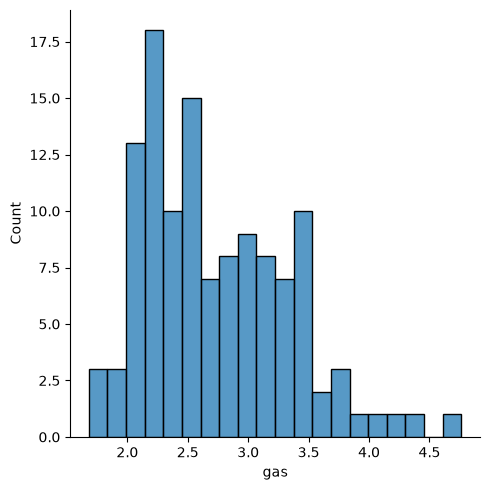

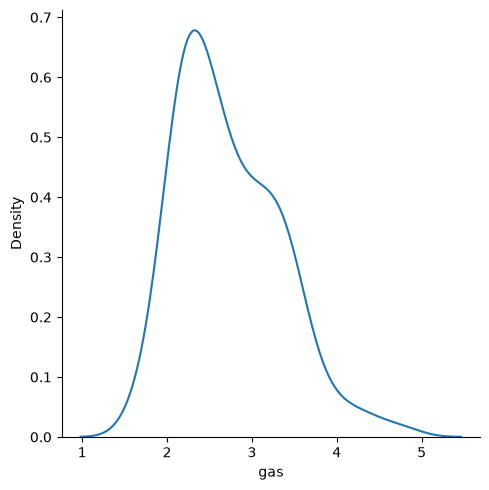

In [27]:
import seaborn as sns

# Prepare econ for plotting: Seaborn wants columns, so move the
# DatetimeIndex back to a regular column
econ_plot = econ.reset_index()

# Histogram of gas prices
sns.displot(data=econ_plot, x="gas", kind="hist", bins=20)
plt.show()

# KDE (also try kind="ecdf")
sns.displot(data=econ_plot, x="gas", kind="kde")
plt.show()

### `sns.relplot()` — Relational Plots

The `sns.relplot()` creates plots of two quantitative variables. The `kind=` argument controls the type of plot where the options are:

- `"scatter"` (default): scatter plot
- `"line"`: line plot

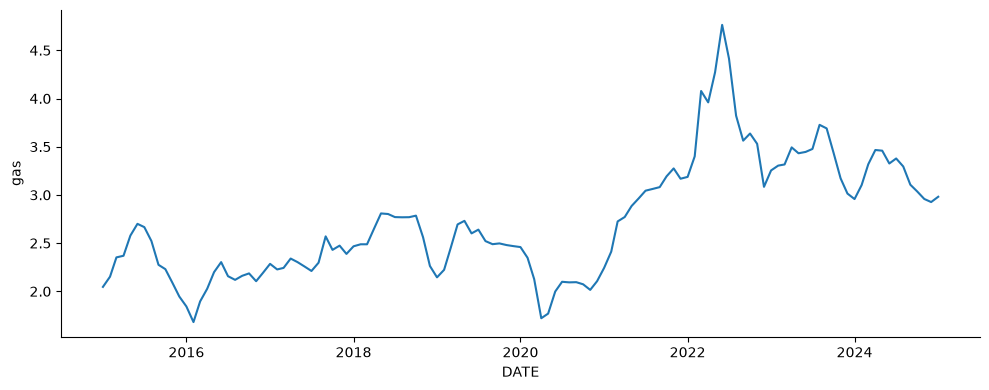

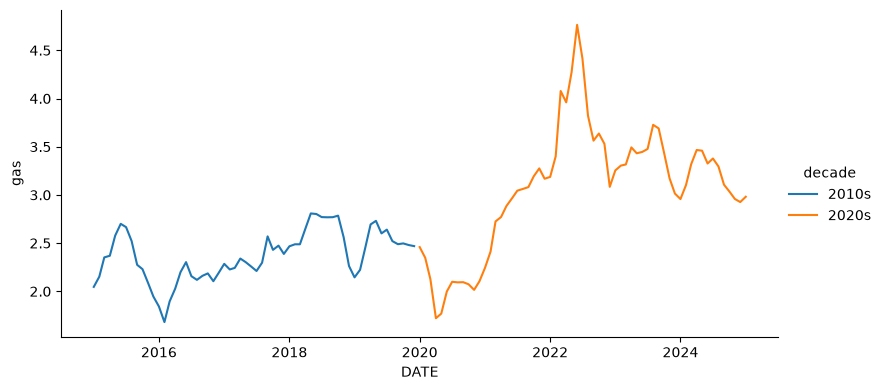

In [28]:
# Line plot: gas prices over time using sns.relplot
sns.relplot(data=econ_plot, x="DATE", y="gas", kind="line",
            height=4, aspect=2.5)
plt.show()

# Add hue to distinguish decades
econ_plot["decade"] = (econ_plot["year"] // 10 * 10).astype(str) + "s"

sns.relplot(data=econ_plot, x="DATE", y="gas",
            hue="decade", kind="line", height=4, aspect=2)
plt.show()

### `sns.catplot()` — Categorical Plots

The `sns.catplot()` plots a quantitative variable as a function of the levels of a categorical variables. The `kind=` argument controls the type of plot where the options are:

- `"strip"` (default): jittered points
- `"swarm"`: creates a bee-swarm plot where points arranged to avoid overlap
- `"box"`: box plot
- `"violin"`: violin plot
- `"boxen"`: box plot variant with more quantiles, for larger datasets
- `"point"`: point estimates with error bars, connected by lines
- `"bar"`: bars of point estimates, with error bars
- `"count"`: bars of category counts

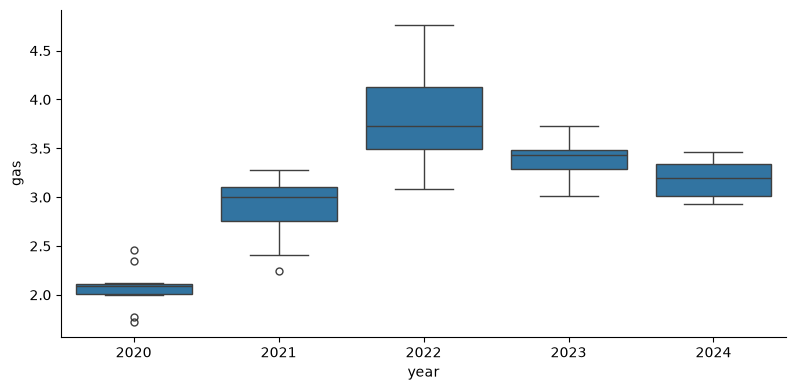

In [29]:
# Box plot: gas price distribution by year
# (.query() supports chained comparisons; 2025 is excluded since it has one month)
recent = econ_plot.query("2020 <= year < 2025")

sns.catplot(data=recent, x="year", y="gas",
            kind="box", height=4, aspect=2)
plt.show()

---
## 3. Statistical Modeling

### StatsModels — Inference

StatsModels uses R-style **formula notation**, so the transition from `lm()` is very straightforward. 

| Goal | R | StatsModels |
|------|---|-------------|
| Fit a linear model | `lm(y ~ x, data=df)` | `smf.ols("y ~ x", data=df).fit()` |
| Model summary | `summary(model)` | `model.summary()` |
| Confidence intervals | `confint(model)` | `model.conf_int()` |

In [30]:
import statsmodels.formula.api as smf

# Fit an OLS model with R-style formula syntax predicting core CPI from gas price
model = smf.ols("CPI ~ gas", data=econ).fit()

# The summary has the same structure as R's summary(lm(...))
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    CPI   R-squared:                       0.633
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     204.9
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.22e-27
Time:                        14:41:32   Log-Likelihood:                -148.67
No. Observations:                 121   AIC:                             301.3
Df Residuals:                     119   BIC:                             306.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.7167      0.350     -4.912      0.0

In [31]:
# Extract specific results
print(model.params)       # coefficients, like coef()
print(model.pvalues)      # p-values
print(model.conf_int())   # confidence intervals, like confint()
print(model.rsquared)     # R-squared

Intercept   -1.716722
gas          1.791486
dtype: float64
Intercept    2.910719e-06
gas          1.222970e-27
dtype: float64
                  0         1
Intercept -2.408825 -1.024620
gas        1.543661  2.039311
0.6325857457458806


> **Where are `dnorm`, `pnorm`, and `qnorm`?** In `scipy.stats` (already installed): `from scipy import stats`. Every distribution object has the same four operations:
>
> | Goal | R | scipy.stats |
> |------|---|-------------|
> | Density | `dnorm(x)` | `stats.norm.pdf(x)` |
> | CDF | `pnorm(x)` | `stats.norm.cdf(x)` |
> | Quantile | `qnorm(p)` | `stats.norm.ppf(p)` |
> | Random draws | `rnorm(n)` | `stats.norm.rvs(size=n)` |
>
> The same pattern applies to `stats.t`, `stats.chi2`, `stats.binom`, and many more. Classical tests live there too: `stats.ttest_ind(x, y)` is `t.test(x, y)`.

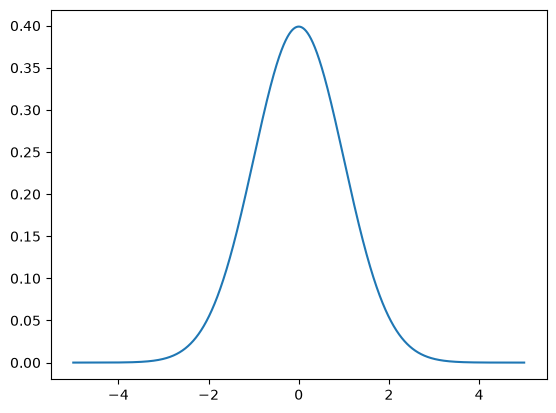

In [32]:
from scipy import stats

# Plot the normal distribution
x_vals = np.linspace(-5, 5, 10000)
plt.plot(x_vals, stats.norm.pdf(x_vals));


## 4. Prediction & Machine Learning with scikit-learn

Scikit-learn is the industry standard package for machine learning. It offers a consistent API across hundreds of algorithms and connects to the broader Python ML ecosystem (PyTorch, TensorFlow, Hugging Face), which is substantially more mature than R's.

**The unified API:** every model in sklearn follows the same three-step interface:
```python
model.fit(X_train, y_train)    # train
model.predict(X_test)          # predict
model.score(X_test, y_test)    # evaluate
```
Switching algorithms means changing one line. The same pattern extends to tools we won't code today: `Pipeline`, `cross_val_score`, `GridSearchCV`, random forests, gradient boosting, and many more.

> **R comparison:** While tidymodels follows a consistent fit/predict workflow, sklearn has wider algorithm coverage.

In [33]:
econ

,CPI,unrate,gas,year
DATE,,,,
2015-01-01,1.976365,5.7,2.046,2015
2015-02-01,1.972517,5.5,2.152,2015
2015-03-01,1.989606,5.4,2.352,2015
2015-04-01,2.053710,5.4,2.369,2015
2015-05-01,2.056561,5.6,2.578,2015
...,...,...,...,...
2024-09-01,4.011582,4.1,3.106,2024
2024-10-01,3.975247,4.1,3.036,2024
2024-11-01,3.890823,4.2,2.958,2024


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# Prepare features and target for predicting CPI from unemployment rate, gas price and year
X = econ[["unrate", "gas", "year"]]   # get predictors: must be 2D DataFrame, not Series
y = econ["CPI"]   # must be a 1D series

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit a LinearRegression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on the test set
y_pred = lr.predict(X_test)

# Evaluate: Cross-validated R-squared and RMSE
r2 = lr.score(X_test, y_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R²:   0.753
RMSE: 0.580


---
## 5. Object-Oriented Python & Duck Typing

Everything in Python is an object. When you call `df.groupby()` or `arr.mean()`, you are calling a **method** on an object. This section shows you how to create your own objects. 

### Defining a Class

```python
class ClassName:
    def __init__(self, arg1, arg2):   # constructor
        self.attr1 = arg1             # attributes
        self.attr2 = arg2

    def method(self):                 # method
        return self.attr1
```

In [35]:
# Define a simple class: a dataset with a name and values
class Dataset:
    def __init__(self, name, values):
        self.name = name
        self.values = values

    def mean(self):
        return sum(self.values) / len(self.values)

# Create an instance
ds = Dataset("egg prices", [2.5, 3.1, 4.0, 5.5])

# Access attributes and call methods
print(ds.name)
print(ds.mean())

egg prices
3.775


### Dunder (Magic) Methods

Python's object model is built on **dunder methods** (double underscore) that are special methods that define how objects behave with built-in functions and syntax.

| Dunder method | Enables |
|---------------|---------|
| `__repr__` | What you see when you evaluate an object in the REPL |
| `__str__` | What `print(obj)` shows |
| `__len__` | `len(obj)` |
| `__getitem__` | `obj[i]` indexing |

In [40]:
class SimpleDataset:
    def __init__(self, name, values):
        self.name = name
        self.values = values

    def __repr__(self):
        return f"SimpleDataset(name={self.name!r}, n={len(self.values)})"

    def __len__(self):
        return len(self.values)

    def __getitem__(self, index):
        return self.values[index]

ds = SimpleDataset("egg prices", [2.5, 3.1, 4.0, 5.5])
print(ds)
print(len(ds))
print(ds[0])

SimpleDataset(name='egg prices', n=4)
4
2.5


### Duck Typing

> *"If it walks like a duck and quacks like a duck, it's a duck."*

Python doesn't check **what class** an object is. It checks **whether the needed methods exist**. Any object that implements `__len__` and `__getitem__` automatically works with `len()`, for-loops, and indexing, with **no inheritance required**.  

Some of Python's core syntax operate on these special methods. Thus if particular special methods are implemented, python code automatically works with these methods. For example, `pd.DataFrame`, `np.ndarray`, `list`, and our custom `SimpleDataset` all work in a `for` loop since they all implement `__getitem__`. 

> **R comparison:** R's S3 dispatches on class *name* (`class(x)`) which is similar to this behavior; e.g., if you set a object's class attribute to say `my_class` and have implemented a function called `my_class.plot()` then this plot function used when the `plot()` function is called on your object. However, inherent R syntax (e.g., for loops) do not rely on these generic methods. 

In [37]:
# SimpleDataset works in a for loop because __getitem__ is defined
ds = SimpleDataset("egg prices", [2.5, 3.1, 4.0, 5.5])
for val in ds:
    print(val)

# And with len()
print(f"Length: {len(ds)}")

# And with indexing
print(f"First value: {ds[0]}")

2.5
3.1
4.0
5.5
Length: 4
First value: 2.5


In [38]:
# list, np.array, pd.Series, and our class all work the same way
# because they all implement __getitem__
objects = [
    ds,
    np.array([1, 2, 3]),
    pd.Series([4, 5, 6]),
    [7, 8, 9],
]

for obj in objects:
    print(f"{type(obj).__name__}: first element = {obj[0]}")

SimpleDataset: first element = 2.5
ndarray: first element = 1
Series: first element = 4
list: first element = 7


---
## Wrap-Up

**You've covered:**
- Python syntax and the key pitfalls for R users
- Core data structures: lists, tuples, dictionaries
- NumPy for vectorized computation
- Pandas for data manipulation (the dplyr of Python)
- Matplotlib and Seaborn for visualization
- StatsModels for inference
- Scikit-learn for machine learning
- Python's object model and duck typing

**Next steps:**
- [Python for Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/) 
- [Python for Data Analysis](https://wesmckinney.com/book/)
- [scikit-learn documentation](https://scikit-learn.org/stable/user_guide.html)
- [Pandas documentation](https://pandas.pydata.org/docs/user_guide/index.html)